# Ensemble Fuzzy v2 — Pertinência Emocional (GoEmotionsPT-BR)

Segunda versão do **Ensemble Fuzzy** que combina os baselines **Logistic Regression + TF-IDF**
e **BERTimbau-base cross-balanced** para detecção multi-label de emoções. Mantém *exatamente*
o mesmo protocolo do `ensemble_fuzzy` (nested CV, calibração 100% out-of-fold, defuzzificação
Centroide/Bisector/MOM) — **não substitui** aquele notebook: lê os mesmos *inputs em cache*
(P_LR, P_BERT, sentimento, léxico) e grava todos os resultados em um diretório **separado**
(`../data/out/ensemble_fuzzy_2`), servindo como comparação lado a lado.

## O que muda em relação à v1 (e por quê)

A v1 rankeava **pior que o BERTimbau sozinho** (ROC-AUC macro 0.852 vs 0.893) e sua precision
caía para perto do LR (0.35). Diagnóstico a partir da base de regras exportada:

1. **As entradas mais informativas recebiam a fuzzificação mais grosseira.** O FCM+FPC dava
   apenas **2 termos** (BAIXO/ALTO) para `p_lr` e `p_bert`, enquanto o léxico de sentimento
   recebia 4. A confiança contínua do BERT — origem da sua precision — era *binarizada*.
   → **v2:** `p_lr` e `p_bert` ganham partição fina dedicada (5 termos, centros por quantis),
   preservando o ranking. É a mudança de maior impacto esperado.

2. **`pos_weight` de até 50× empurrava o consequente para ALTA** e duplicava o balanceamento
   que o limiar por emoção já faz → recall inflado, precision baixa.
   → **v2:** `pos_weight` gentil (`sqrt` do desbalanceamento, teto 4) e o limiar F1 por emoção
   continua fazendo o ajuste fino.

3. **Na zona de desacordo (LR dispara, BERT não), as regras "apostavam no positivo"**
   (~60% ALTA/MÉDIA), recuperando os falsos positivos do LR.
   → **v2:** consequente ALTA exige *lift* mínimo — a taxa de positivos crua da célula tem de
   bater a taxa global (guarda de pureza), cortando ALTA em células de baixa pureza.

4. **T-norma `prod` sobre 6 variáveis diluía os 2 sinais bons** com 4 fracos (sentimento/`outras`
   como ruído multiplicativo).
   → **v2:** núcleo informativo por padrão (`p_lr`, `p_bert`, `sent_pos`, `sent_neg`);
   `sent_neu` (redundante, ≈1−pos−neg) e `outras` (escalar médio quase sem sinal) saem do
   antecedente. A maquinaria continua configurável em `INPUT_VARS`.


In [1]:
# Dependências extras deste notebook (os baselines já cobrem o restante)
# !pip install scikit-fuzzy scipy pandas numpy scikit-learn pyarrow matplotlib imbalanced-learn
# !pip install leia-br


In [2]:
import warnings
warnings.filterwarnings("ignore")

import re
import ast
import json
import time
import numpy as np
import pandas as pd
from pathlib import Path

import skfuzzy as fuzz
from scipy.stats import wilcoxon

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, hamming_loss
)

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ─── Configurações globais ───────────────────────────────────────
RANDOM_STATE  = 42
N_OUTER_FOLDS = 5
TEXT_COL      = "CLEAN_TEXT"

DATA_DIR = Path("../data/treated")
OUT_LR   = Path("../data/out")                       # saídas do baseline LR
OUT_BERT = Path("../data/out/bertimbau")             # saídas do baseline BERTimbau
CKPT_DIR = Path("../data/checkpoints/bertimbau")     # checkpoints por fold

# ── v2: diretório de saída SEPARADO (não sobrescreve o ensemble original) ──
V1_DIR       = Path("../data/out/ensemble_fuzzy")    # resultados/inputs da v1 (p/ comparação)
SHARED_CACHE = V1_DIR / "cache"                      # reaproveita P_LR, P_BERT, SENT, LEX da v1
OUT_DIR      = Path("../data/out/ensemble_fuzzy_2")  # <── todas as saídas da v2 vão aqui
CACHE_DIR    = OUT_DIR / "cache"
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def input_cache_path(fname):
    """Reaproveita o cache de inputs da v1 se existir; senão usa/grava o cache local da v2."""
    shared = SHARED_CACHE / fname
    return shared if shared.exists() else (CACHE_DIR / fname)

# Backend das features de sentimento: "lexicon" (léxico PT, sem GPU) ou "bert"
SENTIMENT_BACKEND = "lexicon"
SENTIMENT_BERT_MODEL = "lxyuan/distilbert-base-multilingual-cased-sentiments-student"

# ── Hiperestrutura do sistema fuzzy (toda calibração ocorre no outer-train) ──
FCM_C_CANDIDATES = (2, 3, 4)     # nº de conjuntos avaliados pelo FPC (variáveis NÃO-prob)
MAX_RULES        = 80            # teto de regras por emoção (subiu: partições mais finas)
T_NORM           = "prod"        # t-norma dos antecedentes
DEFUZZ_METHODS   = ("centroid", "bisector", "mom")
THRESH_GRID      = np.linspace(0.05, 0.95, 19)

# ── v2: correções da análise ─────────────────────────────────────
# (1) entradas de probabilidade recebem partição fina dedicada
PROB_VARS       = ("p_lr", "p_bert")
PROB_N_TERMS    = 5              # nº fixo de termos p/ p_lr e p_bert (centros por quantis)
# (2) balanceamento gentil no consequente (o limiar por emoção faz o ajuste fino)
POS_WEIGHT_MODE = "sqrt"         # {"sqrt","linear","none"}
POS_WEIGHT_CAP  = 4.0
# (3) guarda de pureza: ALTA exige taxa de positivos crua >= LIFT_ALTA * taxa global
LIFT_ALTA       = 1.0
# (4) núcleo informativo (sent_neu e outras saem do antecedente por padrão)
INPUT_VARS      = ["p_lr", "p_bert", "sent_pos", "sent_neg"]

CHANGES_V2 = {
    "prob_inputs_fine_partition": {"vars": list(PROB_VARS), "n_terms": PROB_N_TERMS},
    "pos_weight": {"mode": POS_WEIGHT_MODE, "cap": POS_WEIGHT_CAP},
    "consequente_alta_lift": LIFT_ALTA,
    "input_vars": INPUT_VARS,
    "max_rules": MAX_RULES,
}

EMOTION_COLS = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]
N_LABELS = len(EMOTION_COLS)

ALL_INPUT_VARS = ["p_lr", "p_bert", "sent_pos", "sent_neg", "sent_neu", "outras"]

np.random.seed(RANDOM_STATE)
print(f"Labels: {N_LABELS} | Entradas fuzzy (v2): {INPUT_VARS}")
print(f"Saídas v2 : {OUT_DIR.resolve()}")
print(f"Cache in. : {SHARED_CACHE.resolve()} (reaproveitado se existir)")
print("Mudanças v2:", json.dumps(CHANGES_V2, ensure_ascii=False))


Labels: 28 | Entradas fuzzy (v2): ['p_lr', 'p_bert', 'sent_pos', 'sent_neg']
Saídas v2 : C:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\data\out\ensemble_fuzzy_2
Cache in. : C:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\data\out\ensemble_fuzzy\cache (reaproveitado se existir)
Mudanças v2: {"prob_inputs_fine_partition": {"vars": ["p_lr", "p_bert"], "n_terms": 5}, "pos_weight": {"mode": "sqrt", "cap": 4.0}, "consequente_alta_lift": 1.0, "input_vars": ["p_lr", "p_bert", "sent_pos", "sent_neg"], "max_rules": 80}


## 1–2. Benchmark, protocolo e carregamento dos folds

In [3]:
def load_fold(fold_id: int):
    """Carrega data.parquet e idx.npy de um fold. Retorna (df, idx_array)."""
    fold_dir = DATA_DIR / f"fold_{fold_id}"
    df  = pd.read_parquet(fold_dir / "data.parquet")
    idx = np.load(fold_dir / "idx.npy")
    return df, idx

folds_data = {}
for k in range(1, N_OUTER_FOLDS + 1):
    df_k, idx_k = load_fold(k)
    folds_data[k] = {"df": df_k, "idx": idx_k}
    print(f"Fold {k}: {df_k.shape[0]:>6} amostras | idx shape: {idx_k.shape}")

def prepare_Y(df: pd.DataFrame):
    present = [c for c in EMOTION_COLS if c in df.columns]
    assert len(present) == N_LABELS, f"Faltam labels no parquet: {set(EMOTION_COLS)-set(present)}"
    return df[present].values.astype(int)

Y_folds    = {k: prepare_Y(folds_data[k]["df"]) for k in folds_data}
TEXT_folds = {k: folds_data[k]["df"][TEXT_COL].fillna("").astype(str).values for k in folds_data}

print("\nColunas disponíveis:", folds_data[1]["df"].columns.tolist())


Fold 1:  10831 amostras | idx shape: (10831,)
Fold 2:  10810 amostras | idx shape: (10810,)
Fold 3:  10836 amostras | idx shape: (10836,)
Fold 4:  10909 amostras | idx shape: (10909,)
Fold 5:  10848 amostras | idx shape: (10848,)

Colunas disponíveis: ['id', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral', 'text', 'texto', 'UNCLEAN_TEXT', 'CLEAN_TEXT', 'letter_count', 'sentence_count', 'avg_letter_per_word', 'words_per_sentence', 'avg_syllables_per_word', 'reading_time', 'punctuation_per_word', 'exclamation_per_word', 'question_per_word', 'mean_verbs_per_word', 'mean_auxiliaries_per_word', 'mean_auxiliaries_per_sentence', 'flesch_portuguese', 'uppercase_percentage', 'mean_unique_word_length', 'mean_char_rep

## 3. Predições out-of-fold — `P_LR(emoção)` e `P_BERT(emoção)`

Idêntico à v1: as entradas do sistema fuzzy são **out-of-fold**. Estes inputs são
reaproveitados do cache da v1 (`SHARED_CACHE`) quando disponível — não são recalculados,
e nada da v1 é sobrescrito.

In [4]:
# ─── P_LR: out-of-fold do baseline Logistic Regression ──────────
def load_lr_best_params():
    fp = OUT_LR / "baseline_LR_best_params.csv"
    if not fp.exists():
        print("baseline_LR_best_params.csv não encontrado → usando defaults do baseline.")
        return None
    df = pd.read_csv(fp)
    params = {}
    for _, r in df.iterrows():
        mf = r.get("tfidf__max_features")
        ng = r.get("tfidf__ngram_range")
        p = {
            "max_features": None if pd.isna(mf) else int(mf),
            "ngram_range" : ast.literal_eval(ng) if isinstance(ng, str) else (1, 2),
            "sublinear_tf": bool(r.get("tfidf__sublinear_tf", True)),
            "C"           : 1.0 if pd.isna(r.get("lr__C")) else float(r.get("lr__C")),
        }
        params.setdefault(int(r["fold"]), {})[str(r["label"])] = p
    return params

def compute_lr_oof(missing_folds):
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import LogisticRegression
    from imblearn.over_sampling import SMOTE

    best_params = load_lr_best_params()
    default = {"max_features": 30_000, "ngram_range": (1, 2), "sublinear_tf": True, "C": 1.0}

    for k in missing_folds:
        t0 = time.time()
        X_test_text = TEXT_folds[k]
        train_ks = [j for j in folds_data if j != k]
        X_train_text = np.concatenate([TEXT_folds[j] for j in train_ks])
        Y_train = np.vstack([Y_folds[j] for j in train_ks])

        P = np.zeros((len(X_test_text), N_LABELS), dtype=float)
        for j, lname in enumerate(EMOTION_COLS):
            p = (best_params or {}).get(k, {}).get(lname, default)
            y_j = Y_train[:, j]

            tfidf = TfidfVectorizer(max_features=p["max_features"],
                                    ngram_range=p["ngram_range"],
                                    sublinear_tf=p["sublinear_tf"])
            X_tr = tfidf.fit_transform(X_train_text)
            X_te = tfidf.transform(X_test_text)

            n_pos = int(y_j.sum()); n_neg = len(y_j) - n_pos
            if n_pos >= 2 and n_neg >= 2:
                smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=min(5, n_pos - 1))
                X_res, y_res = smote.fit_resample(X_tr, y_j)
            else:
                X_res, y_res = X_tr, y_j

            lr = LogisticRegression(C=p["C"], solver="saga", max_iter=1000,
                                    random_state=RANDOM_STATE)
            lr.fit(X_res, y_res)
            P[:, j] = lr.predict_proba(X_te)[:, 1]

        np.save(CACHE_DIR / f"P_LR_fold_{k}.npy", P)   # grava no cache da v2
        print(f"  P_LR fold {k} salvo ({time.time()-t0:.0f}s)")

missing = [k for k in folds_data if not input_cache_path(f"P_LR_fold_{k}.npy").exists()]
if missing:
    print(f"Gerando P_LR para folds {missing}...")
    compute_lr_oof(missing)
P_LR_folds = {k: np.load(input_cache_path(f"P_LR_fold_{k}.npy")) for k in folds_data}
print("P_LR OK:", {k: v.shape for k, v in P_LR_folds.items()})


P_LR OK: {1: (10831, 28), 2: (10810, 28), 3: (10836, 28), 4: (10909, 28), 5: (10848, 28)}


In [5]:
# ─── P_BERT: inferência dos checkpoints BERTimbau por fold ──────
def best_epoch_per_fold():
    fp = OUT_BERT / "bertimbau_global_metrics.csv"
    if fp.exists():
        df = pd.read_csv(fp, index_col=0)
        if "epoch" in df.columns:
            return {int(f): int(e) for f, e in df["epoch"].items()}
    return None

def compute_bert_oof(missing_folds):
    import torch
    import torch.nn as nn
    from transformers import AutoTokenizer, AutoModel

    MODEL_NAME = "neuralmind/bert-base-portuguese-cased"
    MAX_LEN, BATCH_SIZE = 128, 64
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    class BERTimbauForEmotions(nn.Module):
        def __init__(self, model_name=MODEL_NAME, n_labels=N_LABELS, dropout=0.1):
            super().__init__()
            self.bert = AutoModel.from_pretrained(model_name)
            self.dropout = nn.Dropout(dropout)
            self.classifier = nn.Linear(self.bert.config.hidden_size, n_labels)
        def forward(self, input_ids, attention_mask):
            out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            return self.classifier(self.dropout(out.last_hidden_state[:, 0, :]))

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    best_eps = best_epoch_per_fold()

    def find_ckpt(fold):
        if best_eps and fold in best_eps:
            fp = CKPT_DIR / f"fold_{fold}_epoch_{best_eps[fold]:02d}.pt"
            if fp.exists():
                return fp
        cands = sorted(CKPT_DIR.glob(f"fold_{fold}_epoch_*.pt"))
        assert cands, f"Nenhum checkpoint encontrado para o fold {fold} em {CKPT_DIR}"
        best_fp, best_f1 = None, -1
        for fp in cands:
            ck = torch.load(fp, map_location="cpu", weights_only=False)
            f1 = ck.get("metrics", {}).get("f1_macro", -1)
            if f1 > best_f1:
                best_fp, best_f1 = fp, f1
            del ck
        return best_fp

    for k in missing_folds:
        t0 = time.time()
        ckpt_path = find_ckpt(k)
        print(f"  Fold {k}: usando {ckpt_path.name}")
        ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        model = BERTimbauForEmotions().to(DEVICE)
        model.load_state_dict(ck["model_state_dict"])
        model.eval()

        texts = TEXT_folds[k].tolist()
        probas = []
        with torch.no_grad():
            for i in range(0, len(texts), BATCH_SIZE):
                enc = tokenizer(texts[i:i + BATCH_SIZE], max_length=MAX_LEN,
                                padding="max_length", truncation=True, return_tensors="pt")
                logits = model(enc["input_ids"].to(DEVICE), enc["attention_mask"].to(DEVICE))
                probas.append(torch.sigmoid(logits).cpu().numpy())
        P = np.vstack(probas)
        np.save(CACHE_DIR / f"P_BERT_fold_{k}.npy", P)
        del model, ck
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
        print(f"  P_BERT fold {k} salvo ({time.time()-t0:.0f}s)")

missing = [k for k in folds_data if not input_cache_path(f"P_BERT_fold_{k}.npy").exists()]
if missing:
    print(f"Gerando P_BERT para folds {missing}...")
    compute_bert_oof(missing)
P_BERT_folds = {k: np.load(input_cache_path(f"P_BERT_fold_{k}.npy")) for k in folds_data}
print("P_BERT OK:", {k: v.shape for k, v in P_BERT_folds.items()})


P_BERT OK: {1: (10831, 28), 2: (10810, 28), 3: (10836, 28), 4: (10909, 28), 5: (10848, 28)}


## 4. Features de Sentimento — `sent_pos`, `sent_neg`, `sent_neu`

Mesmo bloco da v1 (léxico PT ou BERT). Na v2, por padrão apenas `sent_pos` e `sent_neg`
entram no antecedente (`sent_neu` é praticamente redundante, pois pos+neg+neu≈1).

In [6]:
# ─── Léxico embutido (fallback) ──────────────────────────────────
_POS_WORDS = set("""
bom boa bons boas ótimo otimo ótima otima excelente maravilhoso maravilhosa incrível incrivel
adorável adoravel lindo linda legal bacana top perfeito perfeita amei amo adoro adorei gostei
gosto feliz felicidade alegria alegre contente animado animada empolgado empolgada grato grata
gratidão gratidao obrigado obrigada parabéns parabens sucesso vitória vitoria ganhei ganhou
melhor melhores fantástico fantastico sensacional espetacular impressionante admirável admiravel
orgulho orgulhoso orgulhosa esperança esperanca otimista confiante seguro segura tranquilo
tranquila calmo calma paz amor amoroso carinho carinhoso querido querida fofo fofa doce gentil
bondade generoso generosa ajuda apoio incentivo divertido divertida engraçado engracado hilário
hilario risada rir sorrir sorriso curti curtir aprovado aprovo concordo certo certeza justo
interessante curioso curiosa surpreendente maravilha bênção bencao abençoado abencoado alívio
alivio aliviado aliviada satisfeito satisfeita realizado realizada encantado encantada desejo
vontade animação animacao entusiasmo prazer favorito favorita recomendo valeu incrivelmente
""".split())

_NEG_WORDS = set("""
ruim péssimo pessimo péssima pessima horrível horrivel terrível terrivel odeio odiei ódio odio
raiva irritado irritada irritante bravo brava furioso furiosa nervoso nervosa medo assustado
assustada pavor terror pânico panico ansioso ansiosa ansiedade preocupado preocupada triste
tristeza deprimido deprimida depressão depressao chorar chorando lágrima lagrima sofrimento
sofrer dor doloroso dolorosa mágoa magoa magoado magoada decepção decepcao decepcionado
decepcionada frustrado frustrada frustração frustracao desapontado desapontada nojo nojento
nojenta repugnante vergonha envergonhado envergonhada constrangedor constrangido humilhante
humilhado culpa culpado culpada arrependido arrependida remorso lamentável lamentavel lamento
infelizmente infeliz azar fracasso fracassado perdi perdeu derrota falha falhou erro errado
errada injusto injusta absurdo ridículo ridiculo idiota estúpido estupido burro burra chato
chata cansado cansada estresse estressado estressada desisto desistir sozinho sozinha solidão
solidao abandonado abandonada morte morto morta luto perda saudade discordo reprovado detesto
detestável detestavel pior piores nunca jamais problema problemas crise desastre trágico tragico
""".split())

_INTENSIFIERS = set("muito muitíssimo muitissimo extremamente super bem tão tao totalmente "
                    "completamente demais absurdamente incrivelmente realmente".split())
_NEGATIONS = set("não nao nunca jamais nem sem nada nenhum nenhuma".split())

_token_re = re.compile(r"[a-záàâãéêíóôõúüç]+", re.IGNORECASE)

def _lexicon_scores(text: str):
    toks = _token_re.findall(text.lower())
    pos = neg = 0.0
    for i, t in enumerate(toks):
        w = 0.0
        if t in _POS_WORDS: w = 1.0
        elif t in _NEG_WORDS: w = -1.0
        if w == 0.0:
            continue
        window = toks[max(0, i - 3):i]
        if any(x in _INTENSIFIERS for x in window):
            w *= 1.5
        if any(x in _NEGATIONS for x in window):
            w *= -1.0
        if w > 0: pos += w
        else:     neg += -w
    denom = pos + neg + 1.0
    return pos / denom, neg / denom, 1.0 / denom   # somam 1

def sentiment_features_lexicon(texts):
    try:
        from leia import SentimentIntensityAnalyzer
        sia = SentimentIntensityAnalyzer()
        out = np.array([[s["pos"], s["neg"], s["neu"]]
                        for s in (sia.polarity_scores(t) for t in texts)], dtype=float)
        print("  (backend: LeIA)")
        return out
    except Exception:
        return np.array([_lexicon_scores(t) for t in texts], dtype=float)

def sentiment_features_bert(texts, batch_size=64):
    import torch
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tok = AutoTokenizer.from_pretrained(SENTIMENT_BERT_MODEL)
    mdl = AutoModelForSequenceClassification.from_pretrained(SENTIMENT_BERT_MODEL).to(device).eval()
    id2label = {i: l.lower() for i, l in mdl.config.id2label.items()}
    order = [next(i for i, l in id2label.items() if l.startswith(p))
             for p in ("pos", "neg", "neu")]
    outs = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            enc = tok(list(texts[i:i + batch_size]), max_length=128, padding=True,
                      truncation=True, return_tensors="pt").to(device)
            probs = torch.softmax(mdl(**enc).logits, dim=-1).cpu().numpy()
            outs.append(probs[:, order])
    return np.vstack(outs)

def get_sentiment_features():
    sent = {}
    for k in folds_data:
        fp_in = input_cache_path(f"SENT_{SENTIMENT_BACKEND}_fold_{k}.npy")
        if fp_in.exists():
            sent[k] = np.load(fp_in)
            continue
        print(f"Calculando sentimento ({SENTIMENT_BACKEND}) — fold {k}...")
        texts = TEXT_folds[k]
        S = (sentiment_features_bert(texts) if SENTIMENT_BACKEND == "bert"
             else sentiment_features_lexicon(texts))
        np.save(CACHE_DIR / f"SENT_{SENTIMENT_BACKEND}_fold_{k}.npy", S)
        sent[k] = S
    return sent

SENT_folds = get_sentiment_features()   # (n, 3): sent_pos, sent_neg, sent_neu
print("Sentimento OK:", {k: v.shape for k, v in SENT_folds.items()})


Sentimento OK: {1: (10831, 3), 2: (10810, 3), 3: (10836, 3), 4: (10909, 3), 5: (10848, 3)}


## 5. Outras features (léxicas/linguísticas)

Bloco `outras` da v1. Mantido para reprodutibilidade e para permitir reativar via `INPUT_VARS`,
mas **fora do antecedente por padrão** na v2 (escalar médio com pouco sinal para 28 emoções finas).

In [7]:
_elong_re  = re.compile(r"(\w)\1{2,}")
_emoji_re  = re.compile("[\U0001F300-\U0001FAFF\u2600-\u27BF]")
_emot_re   = re.compile(r"[:;=8][\-']?[\)\(dpDP/\\oO3]")

def linguistic_features_from_text(texts):
    feats = np.zeros((len(texts), 6), dtype=float)
    for i, t in enumerate(texts):
        n = max(len(t), 1)
        toks = t.split()
        feats[i, 0] = t.count("!")
        feats[i, 1] = t.count("?")
        feats[i, 2] = sum(1 for c in t if c.isupper()) / n
        feats[i, 3] = len(_elong_re.findall(t))
        feats[i, 4] = len(_emoji_re.findall(t)) + len(_emot_re.findall(t))
        feats[i, 5] = min(len(toks) / 50.0, 1.0)
    return feats

def get_lexical_features():
    df0 = folds_data[1]["df"]
    skip = set(EMOTION_COLS) | {TEXT_COL}
    extra_cols = [c for c in df0.columns
                  if c not in skip and pd.api.types.is_numeric_dtype(df0[c])]
    lex = {}
    if extra_cols:
        print(f"Reaproveitando {len(extra_cols)} features léxicas do parquet: {extra_cols}")
        for k in folds_data:
            lex[k] = folds_data[k]["df"][extra_cols].values.astype(float)
        return lex, extra_cols
    names = ["n_exclam", "n_quest", "caps_ratio", "n_elong", "n_emoji", "len_norm"]
    print("Sem features léxicas no parquet → extraindo do texto:", names)
    for k in folds_data:
        fp_in = input_cache_path(f"LEX_fold_{k}.npy")
        if fp_in.exists():
            lex[k] = np.load(fp_in)
        else:
            lex[k] = linguistic_features_from_text(TEXT_folds[k])
            np.save(CACHE_DIR / f"LEX_fold_{k}.npy", lex[k])
    return lex, names

LEX_folds, LEX_NAMES = get_lexical_features()
print("Features léxicas OK:", {k: v.shape for k, v in LEX_folds.items()})

def aggregate_outras(lex_train, lex_apply):
    """Agrega a matriz léxica em um escalar 'outras' em [0,1] (quantis 1%/99% do treino)."""
    lo = np.quantile(lex_train, 0.01, axis=0)
    hi = np.quantile(lex_train, 0.99, axis=0)
    rng = np.where(hi - lo < 1e-9, 1.0, hi - lo)
    def _t(M):
        return np.clip((M - lo) / rng, 0, 1).mean(axis=1)
    return _t(lex_train), _t(lex_apply)


Reaproveitando 16 features léxicas do parquet: ['letter_count', 'sentence_count', 'avg_letter_per_word', 'words_per_sentence', 'avg_syllables_per_word', 'reading_time', 'punctuation_per_word', 'exclamation_per_word', 'question_per_word', 'mean_verbs_per_word', 'mean_auxiliaries_per_word', 'mean_auxiliaries_per_sentence', 'flesch_portuguese', 'uppercase_percentage', 'mean_unique_word_length', 'mean_char_repetition_per_word']
Features léxicas OK: {1: (10831, 16), 2: (10810, 16), 3: (10836, 16), 4: (10909, 16), 5: (10848, 16)}


## 6. Sistema Fuzzy de Pertinência Emocional — núcleo v2

Mamdani Tipo-1 por emoção. As diferenças da v1 estão concentradas aqui:

- **`prob_fuzzy_variable`** — partição **fina e dedicada** para `p_lr`/`p_bert`
  (`PROB_N_TERMS` termos gaussianos com centros em **quantis** da distribuição de treino).
  Preserva a confiança contínua dos modelos em vez de binarizá-la.
- **`auto_fuzzy_variable`** (FCM/FPC) segue valendo para as variáveis **não-probabilísticas**.
- **`wang_mendel_rules`** — consequente **ALTA** agora exige, além de `s_pos > media_ratio·s_neg`,
  um **lift** de pureza (`taxa_pos_crua ≥ LIFT_ALTA · taxa_global`), atacando a recuperação de
  falsos positivos do LR na zona de desacordo.


In [8]:
# ══════════════════ NÚCLEO DO SISTEMA FUZZY (v2) ══════════════════
_SCALE_NAMES = {
    2: ["baixo", "alto"],
    3: ["baixo", "medio", "alto"],
    4: ["muito_baixo", "baixo", "alto", "muito_alto"],
    5: ["muito_baixo", "baixo", "medio", "alto", "muito_alto"],
    6: ["minimo", "muito_baixo", "baixo", "alto", "muito_alto", "maximo"],
    7: ["minimo", "muito_baixo", "baixo", "medio", "alto", "muito_alto", "maximo"],
}
def term_names_for(n):
    return _SCALE_NAMES.get(n, [f"nivel_{i}" for i in range(n)])

class FuzzyVariable:
    """Variável linguística com funções de pertinência gaussianas."""
    def __init__(self, name, centers, sigmas, term_names):
        order = np.argsort(centers)
        self.name    = name
        self.centers = np.asarray(centers, dtype=float)[order]
        self.sigmas  = np.maximum(np.asarray(sigmas, dtype=float)[order], 0.02)
        self.terms   = [term_names[i] for i in order] if len(term_names) == len(order) \
                       else term_names
    @property
    def n_terms(self):
        return len(self.centers)
    def memberships(self, x):
        x = np.asarray(x, dtype=float).reshape(-1, 1)
        return np.exp(-0.5 * ((x - self.centers[None, :]) / self.sigmas[None, :]) ** 2)


def prob_fuzzy_variable(name, values, n_terms=PROB_N_TERMS):
    """v2 — partição FINA dedicada às entradas de probabilidade (p_lr, p_bert).
    Centros em quantis (adapta-se à assimetria das probabilidades, dando resolução
    onde há dados) — evita a binarização (2 termos) que o FCM produzia na v1."""
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        v = np.array([0.0, 1.0])
    qs = np.linspace(0.02, 0.98, n_terms)
    centers = np.quantile(v, qs)
    centers = np.unique(np.round(centers, 4))
    # se os quantis colapsam (distribuição muito concentrada), cai p/ grade uniforme
    if len(centers) < n_terms or np.ptp(centers) < 1e-3:
        lo, hi = float(np.min(v)), float(np.max(v))
        if hi - lo < 1e-3:
            lo, hi = max(lo - 0.25, 0.0), min(hi + 0.25, 1.0)
        centers = np.unique(np.round(np.linspace(lo, hi, n_terms), 4))
    if len(centers) < 2:
        centers = np.array([0.25, 0.5, 0.75])
    # sigmas ~ 0.6 * espaçamento local entre centros (overlap gaussiano adequado)
    diffs = np.diff(centers)
    sig = np.empty(len(centers))
    sig[0], sig[-1] = diffs[0], diffs[-1]
    for i in range(1, len(centers) - 1):
        sig[i] = 0.5 * (diffs[i - 1] + diffs[i])
    sigmas = np.maximum(sig * 0.6, 0.03)
    return FuzzyVariable(name, centers, sigmas, term_names_for(len(centers)))


def auto_fuzzy_variable(name, values, c_candidates=FCM_C_CANDIDATES,
                        max_points=5000, seed=RANDOM_STATE):
    """Bloco 6 — variável linguística via Fuzzy C-Means (nº de conjuntos pelo FPC).
    Usada apenas para variáveis NÃO-probabilísticas na v2."""
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    rng = np.random.RandomState(seed)
    if len(v) > max_points:
        v = rng.choice(v, size=max_points, replace=False)
    if np.ptp(v) < 1e-6:
        c0 = float(v.mean())
        return FuzzyVariable(name, [max(c0 - .25, 0), c0, min(c0 + .25, 1)],
                             [0.15] * 3, term_names_for(3))
    best = None
    data = v.reshape(1, -1)
    for c in c_candidates:
        try:
            cntr, u, _, _, _, _, fpc = fuzz.cluster.cmeans(
                data, c=c, m=2.0, error=1e-4, maxiter=300, seed=seed)
        except Exception:
            continue
        cs = np.sort(cntr.ravel())
        if c > 1 and np.min(np.diff(cs)) < 1e-3:
            continue
        if best is None or fpc > best[0]:
            best = (fpc, cntr.ravel(), u)
    if best is None:
        qs = np.quantile(v, [0.1, 0.5, 0.9])
        return FuzzyVariable(name, qs, [0.15] * 3, term_names_for(3))
    _, centers, u = best
    sigmas = []
    for i, ci in enumerate(centers):
        um = u[i] ** 2.0
        var = np.sum(um * (v - ci) ** 2) / max(np.sum(um), 1e-12)
        sigmas.append(np.sqrt(max(var, 1e-6)))
    return FuzzyVariable(name, centers, sigmas, term_names_for(len(centers)))


def make_fuzzy_variable(name, values):
    """Dispatcher v2: partição fina p/ probabilidades; FCM/FPC p/ o resto."""
    if name in PROB_VARS:
        return prob_fuzzy_variable(name, values)
    return auto_fuzzy_variable(name, values)


# ── Variável de saída: pertinência emocional em [0,1] ────────────
Z_UNIVERSE  = np.linspace(0.0, 1.0, 101)
OUT_TERMS   = ["baixa", "media", "alta"]
OUT_CENTERS = np.array([0.0, 0.5, 1.0])
OUT_SIGMA   = 0.15
OUT_MU = np.exp(-0.5 * ((Z_UNIVERSE[None, :] - OUT_CENTERS[:, None]) / OUT_SIGMA) ** 2)  # (3,101)


def wang_mendel_rules(M_list, y, pos_weight=1.0, max_rules=MAX_RULES,
                      media_ratio=1.25, lift_alta=LIFT_ALTA):
    """Bloco 7 (v2) — base de regras Wang–Mendel.
    ALTA exige s_pos > media_ratio·s_neg **E** lift de pureza (taxa crua ≥ lift·taxa_global)."""
    best_terms = np.stack([M.argmax(1) for M in M_list], axis=1)   # (n, n_vars)
    best_degs  = np.stack([M.max(1)   for M in M_list], axis=1)
    deg = best_degs.prod(axis=1)
    w   = deg * np.where(y == 1, pos_weight, 1.0)                  # balanceamento (gentil na v2)

    radices = np.array([M.shape[1] for M in M_list])
    mult = np.concatenate([[1], np.cumprod(radices[:-1])])
    codes = (best_terms * mult[None, :]).sum(1)

    uniq, inv = np.unique(codes, return_inverse=True)
    s_pos = np.zeros(len(uniq)); s_neg = np.zeros(len(uniq))       # ponderados
    c_pos = np.zeros(len(uniq)); c_neg = np.zeros(len(uniq))       # crus (p/ lift)
    np.add.at(s_pos, inv[y == 1], w[y == 1])
    np.add.at(s_neg, inv[y == 0], w[y == 0])
    np.add.at(c_pos, inv[y == 1], 1.0)
    np.add.at(c_neg, inv[y == 0], 1.0)
    global_rate = float(y.mean())

    rules = []
    for i, cd in enumerate(uniq):
        sp, sn = s_pos[i], s_neg[i]
        tot = sp + sn
        if tot <= 0:
            continue
        craw = c_pos[i] + c_neg[i]
        raw_rate = (c_pos[i] / craw) if craw > 0 else 0.0
        alta_ok  = (sp > media_ratio * sn) and (raw_rate >= lift_alta * global_rate)
        if alta_ok:                      cons, conf = 2, sp / tot                    # ALTA
        elif sn > media_ratio * sp:      cons, conf = 0, sn / tot                    # BAIXA
        else:                            cons, conf = 1, 1 - abs(sp - sn) / tot      # MÉDIA
        ant, c = [], int(cd)
        for r in radices:
            ant.append(c % r); c //= r
        rules.append(dict(antecedent=tuple(int(a) for a in ant),
                          consequent=int(cons), conf=float(conf), support=float(tot)))
    rules.sort(key=lambda r: r["support"], reverse=True)
    return rules[:max_rules]


def fuzzy_inference(M_list, rules, t_norm=T_NORM):
    """Bloco 8 (parte 1) — inferência Mamdani vetorizada → W (n, 3)."""
    n = M_list[0].shape[0]
    W = np.zeros((n, len(OUT_TERMS)))
    for r in rules:
        parts = np.stack([M_list[i][:, a] for i, a in enumerate(r["antecedent"])], axis=1)
        fire = parts.prod(1) if t_norm == "prod" else parts.min(1)
        fire = fire * r["conf"]
        j = r["consequent"]
        W[:, j] = np.maximum(W[:, j], fire)
    return W


def defuzzify(W, methods=DEFUZZ_METHODS):
    """Bloco 8 (parte 2) — defuzzificação vetorizada → {método: graus (n,) em [0,1]}."""
    agg = np.minimum(W[:, :, None], OUT_MU[None, :, :]).max(axis=1)   # (n, 101)
    z = Z_UNIVERSE
    s = agg.sum(1); s_safe = np.where(s <= 0, 1.0, s)
    out = {}
    if "centroid" in methods:
        cen = (agg * z[None, :]).sum(1) / s_safe
        out["centroid"] = np.where(s <= 0, 0.0, cen)
    if "bisector" in methods:
        cum = np.cumsum(agg, 1)
        idx = (cum >= (s_safe / 2.0)[:, None]).argmax(1)
        out["bisector"] = np.where(s <= 0, 0.0, z[idx])
    if "mom" in methods:
        mx = agg.max(1)
        mask = agg >= (mx[:, None] - 1e-12)
        mom = (mask * z[None, :]).sum(1) / mask.sum(1)
        out["mom"] = np.where(mx <= 0, 0.0, mom)
    return out


def rule_to_text(rule, fvars, emotion):
    ant = " E ".join(f"{fv.name} é {fv.terms[a].upper()}"
                     for fv, a in zip(fvars, rule["antecedent"]))
    return (f"SE {ant} ENTÃO pertinência({emotion}) é "
            f"{OUT_TERMS[rule['consequent']].upper()}  "
            f"[conf={rule['conf']:.2f}, suporte={rule['support']:.1f}]")

print("Núcleo fuzzy v2 carregado (partição fina p/ p_lr/p_bert + lift no consequente ALTA).")


Núcleo fuzzy v2 carregado (partição fina p/ p_lr/p_bert + lift no consequente ALTA).


In [9]:
# ══════ Calibração (outer-train) e aplicação (outer-test) por emoção — v2 ══════
def build_emotion_inputs(j, p_lr, p_bert, sent, outras):
    """Monta as entradas do sistema fuzzy da emoção j (só as que estão em INPUT_VARS)."""
    full = {
        "p_lr"    : p_lr[:, j],
        "p_bert"  : p_bert[:, j],
        "sent_pos": sent[:, 0],
        "sent_neg": sent[:, 1],
        "sent_neu": sent[:, 2],
        "outras"  : outras,
    }
    return {v: full[v] for v in INPUT_VARS}

def _pos_weight(n_pos, n_total):
    n_neg = n_total - n_pos
    imb = n_neg / max(n_pos, 1)
    if POS_WEIGHT_MODE == "none":
        return 1.0
    if POS_WEIGHT_MODE == "linear":
        return float(np.clip(imb, 1.0, POS_WEIGHT_CAP))
    return float(np.clip(np.sqrt(imb), 1.0, POS_WEIGHT_CAP))   # "sqrt" (default v2)

def fit_fuzzy_emotion(inputs_cal, y_cal):
    """Calibra o sistema fuzzy de UMA emoção no outer-train (v2)."""
    fvars  = [make_fuzzy_variable(v, inputs_cal[v]) for v in INPUT_VARS]
    M_cal  = [fv.memberships(inputs_cal[fv.name]) for fv in fvars]

    n_pos = int(y_cal.sum())
    pw = _pos_weight(n_pos, len(y_cal))
    rules = wang_mendel_rules(M_cal, y_cal, pos_weight=pw)

    W_cal    = fuzzy_inference(M_cal, rules)
    pert_cal = defuzzify(W_cal)

    thresholds, f1_cal = {}, {}
    for m, p in pert_cal.items():
        best_t, best_f1 = 0.5, -1.0
        if n_pos > 0:
            for t in THRESH_GRID:
                f1 = f1_score(y_cal, (p >= t).astype(int), zero_division=0)
                if f1 > best_f1:
                    best_t, best_f1 = float(t), f1
        thresholds[m] = best_t
        f1_cal[m] = max(best_f1, 0.0)

    return dict(fvars=fvars, rules=rules, thresholds=thresholds,
                f1_cal=f1_cal, pos_weight=float(pw))

def apply_fuzzy_emotion(system, inputs):
    M = [fv.memberships(inputs[fv.name]) for fv in system["fvars"]]
    W = fuzzy_inference(M, system["rules"])
    return defuzzify(W)

def compute_metrics(Y_true, Y_pred, Y_score, label_names):
    metrics = {
        "accuracy"       : accuracy_score(Y_true, Y_pred),
        "hamming_loss"   : hamming_loss(Y_true, Y_pred),
        "f1_macro"       : f1_score(Y_true, Y_pred, average="macro",    zero_division=0),
        "f1_micro"       : f1_score(Y_true, Y_pred, average="micro",    zero_division=0),
        "f1_weighted"    : f1_score(Y_true, Y_pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(Y_true, Y_pred, average="macro", zero_division=0),
        "recall_macro"   : recall_score(Y_true, Y_pred, average="macro",    zero_division=0),
    }
    valid = [j for j in range(Y_true.shape[1]) if Y_true[:, j].sum() > 0]
    metrics["roc_auc_macro"] = (roc_auc_score(Y_true[:, valid], Y_score[:, valid],
                                              average="macro") if valid else np.nan)
    metrics["f1_per_label"] = dict(zip(label_names,
                                       f1_score(Y_true, Y_pred, average=None, zero_division=0)))
    return metrics

print("Funções de calibração/aplicação (v2) prontas.")


Funções de calibração/aplicação (v2) prontas.


## 7. Nested CV — loop principal do Ensemble Fuzzy (v2)

Mesmo protocolo da v1: para cada outer fold, calibra por emoção no outer-train (OOF),
aplica no outer-test, seleciona o método de defuzzificação pela F1 de calibração.

In [10]:
all_fold_metrics    = []
method_fold_metrics = {m: [] for m in DEFUZZ_METHODS}
lr_fold_metrics     = []
bert_fold_metrics   = []
fuzzy_systems       = {}
pertinence_test     = {}
selected_methods    = {}
pred_store          = {}

for outer_k in range(1, N_OUTER_FOLDS + 1):
    t0 = time.time()
    print(f"\n{'='*60}\n  OUTER FOLD {outer_k}/{N_OUTER_FOLDS}\n{'='*60}")

    train_ks = [j for j in folds_data if j != outer_k]

    p_lr_cal   = np.vstack([P_LR_folds[j]   for j in train_ks])
    p_bert_cal = np.vstack([P_BERT_folds[j] for j in train_ks])
    sent_cal   = np.vstack([SENT_folds[j]   for j in train_ks])
    lex_cal    = np.vstack([LEX_folds[j]    for j in train_ks])
    Y_cal      = np.vstack([Y_folds[j]      for j in train_ks])

    p_lr_te, p_bert_te = P_LR_folds[outer_k], P_BERT_folds[outer_k]
    sent_te, lex_te    = SENT_folds[outer_k], LEX_folds[outer_k]
    Y_te               = Y_folds[outer_k]
    n_te               = Y_te.shape[0]

    outras_cal, outras_te = aggregate_outras(lex_cal, lex_te)
    print(f"  Calibração: {len(Y_cal):>6} | Teste: {n_te:>5}")

    systems = {}
    pert_te = {m: np.zeros((n_te, N_LABELS)) for m in DEFUZZ_METHODS}
    f1_cal_by_method = {m: [] for m in DEFUZZ_METHODS}

    for j, emo in enumerate(EMOTION_COLS):
        inp_cal = build_emotion_inputs(j, p_lr_cal, p_bert_cal, sent_cal, outras_cal)
        inp_te  = build_emotion_inputs(j, p_lr_te,  p_bert_te,  sent_te,  outras_te)

        sysj = fit_fuzzy_emotion(inp_cal, Y_cal[:, j])
        systems[emo] = sysj

        pj = apply_fuzzy_emotion(sysj, inp_te)
        for m in DEFUZZ_METHODS:
            pert_te[m][:, j] = pj[m]
            f1_cal_by_method[m].append(sysj["f1_cal"][m])

    fuzzy_systems[outer_k]   = systems
    pertinence_test[outer_k] = pert_te

    f1_cal_macro = {m: float(np.mean(v)) for m, v in f1_cal_by_method.items()}
    sel = max(f1_cal_macro, key=f1_cal_macro.get)
    selected_methods[outer_k] = sel
    print("  F1-Macro (calibração) por defuzz:",
          {m: round(v, 4) for m, v in f1_cal_macro.items()}, f"→ selecionado: {sel}")

    fold_preds = {}
    for m in DEFUZZ_METHODS:
        thr = np.array([systems[e]["thresholds"][m] for e in EMOTION_COLS])
        Y_pred_m = (pert_te[m] >= thr[None, :]).astype(int)
        fold_preds[m] = Y_pred_m
        mm = compute_metrics(Y_te, Y_pred_m, pert_te[m], EMOTION_COLS)
        mm["outer_fold"] = outer_k
        method_fold_metrics[m].append(mm)

    fm = dict(method_fold_metrics[sel][-1])
    fm["defuzz"] = sel
    fm["elapsed_s"] = round(time.time() - t0, 1)
    all_fold_metrics.append(fm)

    lr_pred, bert_pred = (p_lr_te >= 0.5).astype(int), (p_bert_te >= 0.5).astype(int)
    mlr = compute_metrics(Y_te, lr_pred, p_lr_te, EMOTION_COLS); mlr["outer_fold"] = outer_k
    mbt = compute_metrics(Y_te, bert_pred, p_bert_te, EMOTION_COLS); mbt["outer_fold"] = outer_k
    lr_fold_metrics.append(mlr); bert_fold_metrics.append(mbt)

    pred_store[outer_k] = dict(fuzzy=fold_preds[sel], lr=lr_pred, bert=bert_pred)

    print(f"  Fuzzy ({sel}) | F1-Macro: {fm['f1_macro']:.4f} | "
          f"P-Macro: {fm['precision_macro']:.4f} | R-Macro: {fm['recall_macro']:.4f} | "
          f"AUC: {fm['roc_auc_macro']:.4f}")
    print(f"  LR           | F1-Macro: {mlr['f1_macro']:.4f} | "
          f"P-Macro: {mlr['precision_macro']:.4f} | R-Macro: {mlr['recall_macro']:.4f} | "
          f"AUC: {mlr['roc_auc_macro']:.4f}")
    print(f"  BERTimbau    | F1-Macro: {mbt['f1_macro']:.4f} | "
          f"P-Macro: {mbt['precision_macro']:.4f} | R-Macro: {mbt['recall_macro']:.4f} | "
          f"AUC: {mbt['roc_auc_macro']:.4f}")
    print(f"  Tempo: {fm['elapsed_s']}s")

print("\n✓ Nested CV do Ensemble Fuzzy v2 concluído.")



  OUTER FOLD 1/5
  Calibração:  43403 | Teste: 10831
  F1-Macro (calibração) por defuzz: {'centroid': 0.4086, 'bisector': 0.4119, 'mom': 0.4084} → selecionado: bisector
  Fuzzy (bisector) | F1-Macro: 0.4191 | P-Macro: 0.3803 | R-Macro: 0.4980 | AUC: 0.8316
  LR           | F1-Macro: 0.3695 | P-Macro: 0.3324 | R-Macro: 0.4560 | AUC: 0.8375
  BERTimbau    | F1-Macro: 0.3999 | P-Macro: 0.6283 | R-Macro: 0.3417 | AUC: 0.8921
  Tempo: 16.1s

  OUTER FOLD 2/5
  Calibração:  43424 | Teste: 10810
  F1-Macro (calibração) por defuzz: {'centroid': 0.4068, 'bisector': 0.4069, 'mom': 0.4071} → selecionado: mom
  Fuzzy (mom) | F1-Macro: 0.4059 | P-Macro: 0.3590 | R-Macro: 0.5507 | AUC: 0.8555
  LR           | F1-Macro: 0.3608 | P-Macro: 0.3172 | R-Macro: 0.4587 | AUC: 0.8414
  BERTimbau    | F1-Macro: 0.4110 | P-Macro: 0.6144 | R-Macro: 0.3439 | AUC: 0.8975
  Tempo: 14.0s

  OUTER FOLD 3/5
  Calibração:  43398 | Teste: 10836
  F1-Macro (calibração) por defuzz: {'centroid': 0.4209, 'bisector': 0.417

## 8. Avaliação — métricas globais por outer fold (média ± desvio-padrão)

In [11]:
global_metric_keys = [
    "outer_fold", "accuracy", "hamming_loss",
    "f1_macro", "f1_micro", "f1_weighted",
    "precision_macro", "recall_macro", "roc_auc_macro", "defuzz", "elapsed_s"
]
rows = [{k: m.get(k) for k in global_metric_keys} for m in all_fold_metrics]
df_results = pd.DataFrame(rows).set_index("outer_fold")

numeric_cols = [c for c in df_results.columns if c not in ("elapsed_s", "defuzz")]
mean_row = df_results[numeric_cols].mean().rename("mean")
std_row  = df_results[numeric_cols].std().rename("std")
df_summary = pd.concat([df_results[numeric_cols], mean_row.to_frame().T, std_row.to_frame().T])

print("\n===== ENSEMBLE FUZZY v2 — MÉTRICAS GLOBAIS POR OUTER FOLD =====")
display(df_results.round(4))

print("\n===== RESUMO (média ± desvio-padrão) =====")
display(df_summary.round(4))

defuzz_rows = []
for m in DEFUZZ_METHODS:
    dfm = pd.DataFrame([{k: x[k] for k in numeric_cols} for x in method_fold_metrics[m]])
    r = {"defuzz": m}
    for c in ["f1_macro", "f1_micro", "precision_macro", "recall_macro", "roc_auc_macro"]:
        r[c] = f"{dfm[c].mean():.4f} ± {dfm[c].std():.4f}"
    defuzz_rows.append(r)
df_defuzz = pd.DataFrame(defuzz_rows).set_index("defuzz")
print("\n===== DEFUZZIFICAÇÃO: Centroide vs Bisector vs MOM (média ± DP) =====")
display(df_defuzz)
print("Métodos selecionados por fold (na calibração):", selected_methods)



===== ENSEMBLE FUZZY v2 — MÉTRICAS GLOBAIS POR OUTER FOLD =====


,accuracy,hamming_loss,f1_macro,f1_micro,f1_weighted,precision_macro,recall_macro,roc_auc_macro,defuzz,elapsed_s
outer_fold,,,,,,,,,,
1,0.3406,0.0459,0.4191,0.5203,0.5295,0.3803,0.4980,0.8316,bisector,16.1
2,0.2451,0.0622,0.4059,0.4554,0.5249,0.3590,0.5507,0.8555,mom,14.0
3,0.2071,0.0618,0.4146,0.4492,0.5264,0.3771,0.5221,0.8433,mom,14.0
4,0.3251,0.0501,0.4141,0.4994,0.5246,0.3739,0.4992,0.8209,bisector,14.3
5,0.3063,0.0517,0.4158,0.4928,0.5216,0.3718,0.5087,0.8268,bisector,14.5



===== RESUMO (média ± desvio-padrão) =====


,accuracy,hamming_loss,f1_macro,f1_micro,f1_weighted,precision_macro,recall_macro,roc_auc_macro
1,0.3406,0.0459,0.4191,0.5203,0.5295,0.3803,0.4980,0.8316
2,0.2451,0.0622,0.4059,0.4554,0.5249,0.3590,0.5507,0.8555
3,0.2071,0.0618,0.4146,0.4492,0.5264,0.3771,0.5221,0.8433
4,0.3251,0.0501,0.4141,0.4994,0.5246,0.3739,0.4992,0.8209
5,0.3063,0.0517,0.4158,0.4928,0.5216,0.3718,0.5087,0.8268
mean,0.2848,0.0543,0.4139,0.4834,0.5254,0.3724,0.5157,0.8356
std,0.0566,0.0073,0.0049,0.0302,0.0029,0.0081,0.0218,0.0138



===== DEFUZZIFICAÇÃO: Centroide vs Bisector vs MOM (média ± DP) =====


,f1_macro,f1_micro,precision_macro,recall_macro,roc_auc_macro
defuzz,,,,,
centroid,0.4120 ± 0.0038,0.4919 ± 0.0202,0.3769 ± 0.0069,0.4991 ± 0.0087,0.8444 ± 0.0116
bisector,0.4137 ± 0.0042,0.4852 ± 0.0369,0.3764 ± 0.0059,0.5071 ± 0.0100,0.8266 ± 0.0089
mom,0.4126 ± 0.0048,0.4701 ± 0.0272,0.3683 ± 0.0065,0.5264 ± 0.0140,0.8520 ± 0.0098


Métodos selecionados por fold (na calibração): {1: 'bisector', 2: 'mom', 3: 'mom', 4: 'bisector', 5: 'bisector'}


## 9. Comparação de desempenho — LR vs BERTimbau vs Ensemble Fuzzy v2 (e vs v1)

Além dos baselines e do teste de Wilcoxon, esta célula carrega — se existir — o resumo do
`ensemble_fuzzy` **original** para comparar v1 × v2 lado a lado. O alvo do diagnóstico é o
**ROC-AUC macro**: a v2 deve deixar de rankear abaixo do BERTimbau.

In [12]:
def folds_df(metric_list):
    keys = ["accuracy", "precision_macro", "recall_macro",
            "f1_macro", "f1_micro", "roc_auc_macro", "hamming_loss"]
    return pd.DataFrame([{k: m[k] for k in keys} for m in metric_list],
                        index=[m["outer_fold"] for m in metric_list])

df_lr, df_bert, df_fz = folds_df(lr_fold_metrics), folds_df(bert_fold_metrics), folds_df(all_fold_metrics)

comp_rows = []
for name, d in [("Logistic Regression", df_lr),
                ("BERTimbau", df_bert),
                ("Ensemble Fuzzy v2", df_fz)]:
    r = {"Modelo": name}
    for c in ["accuracy", "precision_macro", "recall_macro", "f1_macro", "f1_micro", "roc_auc_macro"]:
        r[c] = f"{d[c].mean():.4f} ± {d[c].std():.4f}"
    comp_rows.append(r)
df_comparison = pd.DataFrame(comp_rows).set_index("Modelo")
print("===== COMPARAÇÃO DE DESEMPENHO (média ± DP, 5 outer folds) =====")
display(df_comparison)

# ── Comparação v1 × v2 (se o resumo da v1 existir) ───────────────
df_v1v2 = None
v1_csv = V1_DIR / "ensemble_fuzzy_global_metrics.csv"
if v1_csv.exists():
    try:
        df_v1 = pd.read_csv(v1_csv, index_col=0)
        met = ["f1_macro", "f1_micro", "precision_macro", "recall_macro", "roc_auc_macro"]
        rows_c = []
        for nm, d in [("Ensemble Fuzzy v1", df_v1), ("Ensemble Fuzzy v2", df_results)]:
            rows_c.append({"Versão": nm, **{c: f"{d[c].mean():.4f} ± {d[c].std():.4f}" for c in met}})
        df_v1v2 = pd.DataFrame(rows_c).set_index("Versão")
        print("\n===== ENSEMBLE FUZZY: v1 vs v2 (média ± DP) =====")
        display(df_v1v2)
        print("Δ (v2 − v1):", {c: round(df_results[c].mean() - df_v1[c].mean(), 4) for c in met})
    except Exception as e:
        print("Não foi possível carregar métricas da v1:", e)
else:
    print("\n(Resumo da v1 não encontrado em", v1_csv, "— rode o ensemble_fuzzy original p/ comparar.)")

def wtest(a, b):
    try:
        stat, p = wilcoxon(a, b); return float(stat), float(p)
    except ValueError:
        return np.nan, np.nan

wilcoxon_results = {}
for other_name, d_other in [("LR", df_lr), ("BERTimbau", df_bert)]:
    s5, p5 = wtest(df_fz["f1_macro"].values, d_other["f1_macro"].values)
    wilcoxon_results[f"Fuzzy v2 vs {other_name} (F1-Macro por fold, n=5)"] = {"statistic": s5, "p_value": p5}

def f1_label_matrix(metric_list):
    return pd.DataFrame([m["f1_per_label"] for m in metric_list]).mean()

f1lab_fz, f1lab_lr, f1lab_bt = (f1_label_matrix(all_fold_metrics),
                                f1_label_matrix(lr_fold_metrics),
                                f1_label_matrix(bert_fold_metrics))
for other_name, ser in [("LR", f1lab_lr), ("BERTimbau", f1lab_bt)]:
    s28, p28 = wtest(f1lab_fz.values, ser.values)
    wilcoxon_results[f"Fuzzy v2 vs {other_name} (F1 por label, n=28)"] = {"statistic": s28, "p_value": p28}

print("\n===== TESTE DE WILCOXON =====")
for k, v in wilcoxon_results.items():
    sig = "✓ significativo (α=0.05)" if (not np.isnan(v["p_value"]) and v["p_value"] < 0.05) else "n.s."
    print(f"  {k}: W={v['statistic']:.1f}, p={v['p_value']:.4f}  {sig}")


===== COMPARAÇÃO DE DESEMPENHO (média ± DP, 5 outer folds) =====


,accuracy,precision_macro,recall_macro,f1_macro,f1_micro,roc_auc_macro
Modelo,,,,,,
Logistic Regression,0.1873 ± 0.0088,0.3240 ± 0.0088,0.4652 ± 0.0075,0.3655 ± 0.0052,0.4152 ± 0.0054,0.8390 ± 0.0017
BERTimbau,0.3827 ± 0.0067,0.6072 ± 0.0212,0.3415 ± 0.0066,0.3990 ± 0.0095,0.5069 ± 0.0068,0.8930 ± 0.0026
Ensemble Fuzzy v2,0.2848 ± 0.0566,0.3724 ± 0.0081,0.5157 ± 0.0218,0.4139 ± 0.0049,0.4834 ± 0.0302,0.8356 ± 0.0138



===== ENSEMBLE FUZZY: v1 vs v2 (média ± DP) =====


,f1_macro,f1_micro,precision_macro,recall_macro,roc_auc_macro
Versão,,,,,
Ensemble Fuzzy v1,0.4008 ± 0.0051,0.4457 ± 0.0045,0.3465 ± 0.0078,0.5495 ± 0.0074,0.8521 ± 0.0046
Ensemble Fuzzy v2,0.4139 ± 0.0049,0.4834 ± 0.0302,0.3724 ± 0.0081,0.5157 ± 0.0218,0.8356 ± 0.0138


Δ (v2 − v1): {'f1_macro': np.float64(0.0132), 'f1_micro': np.float64(0.0377), 'precision_macro': np.float64(0.0259), 'recall_macro': np.float64(-0.0338), 'roc_auc_macro': np.float64(-0.0165)}

===== TESTE DE WILCOXON =====
  Fuzzy v2 vs LR (F1-Macro por fold, n=5): W=0.0, p=0.0625  n.s.
  Fuzzy v2 vs BERTimbau (F1-Macro por fold, n=5): W=1.0, p=0.1250  n.s.
  Fuzzy v2 vs LR (F1 por label, n=28): W=79.0, p=0.0037  ✓ significativo (α=0.05)
  Fuzzy v2 vs BERTimbau (F1 por label, n=28): W=170.0, p=0.4652  n.s.


In [13]:
f1_per_label_folds = pd.DataFrame(
    [m["f1_per_label"] for m in all_fold_metrics],
    index=[f"fold_{m['outer_fold']}" for m in all_fold_metrics]
)
f1_per_label_mean = f1_per_label_folds.mean().sort_values(ascending=False)

print("===== ENSEMBLE FUZZY v2 — F1 POR LABEL (média entre folds) =====")
display(pd.DataFrame({"F1 Médio": f1_per_label_mean,
                      "Std": f1_per_label_folds.std()}).round(4))

df_label_comp = pd.DataFrame({"Fuzzy": f1lab_fz, "LR": f1lab_lr, "BERTimbau": f1lab_bt})
df_label_comp["Δ vs LR"]   = df_label_comp["Fuzzy"] - df_label_comp["LR"]
df_label_comp["Δ vs BERT"] = df_label_comp["Fuzzy"] - df_label_comp["BERTimbau"]
df_label_comp["Δ vs melhor baseline"] = df_label_comp["Fuzzy"] - df_label_comp[["LR", "BERTimbau"]].max(axis=1)

print("\n===== F1 POR LABEL: FUZZY v2 vs BASELINES (ordenado pelo ganho) =====")
display(df_label_comp.sort_values("Δ vs melhor baseline", ascending=False).round(4))

n_beat_both = int((df_label_comp["Δ vs melhor baseline"] > 0).sum())
print(f"\nEmoções em que o Fuzzy v2 supera AMBOS os baselines: {n_beat_both}/{N_LABELS}")


===== ENSEMBLE FUZZY v2 — F1 POR LABEL (média entre folds) =====


,F1 Médio,Std
admiration,0.6458,0.0100
amusement,0.7549,0.0114
anger,0.4186,0.0265
annoyance,0.2797,0.0078
approval,0.2827,0.0113
caring,0.3832,0.0099
confusion,0.3084,0.0636
curiosity,0.3553,0.0123
desire,0.4123,0.0270
disappointment,0.2232,0.0290



===== F1 POR LABEL: FUZZY v2 vs BASELINES (ordenado pelo ganho) =====


,Fuzzy,LR,BERTimbau,Δ vs LR,Δ vs BERT,Δ vs melhor baseline
curiosity,0.3553,0.2179,0.1828,0.1374,0.1725,0.1374
disapproval,0.3475,0.2326,0.1356,0.1150,0.2119,0.1150
caring,0.3832,0.2909,0.2958,0.0923,0.0874,0.0874
approval,0.2827,0.2080,0.0945,0.0747,0.1882,0.0747
annoyance,0.2797,0.2092,0.0045,0.0706,0.2752,0.0706
anger,0.4186,0.2993,0.3503,0.1193,0.0683,0.0683
neutral,0.6454,0.5798,0.5857,0.0655,0.0596,0.0596
disappointment,0.2232,0.1650,0.0598,0.0582,0.1635,0.0582
sadness,0.4999,0.3926,0.4637,0.1073,0.0363,0.0363
admiration,0.6458,0.6092,0.6149,0.0366,0.0309,0.0309



Emoções em que o Fuzzy v2 supera AMBOS os baselines: 14/28


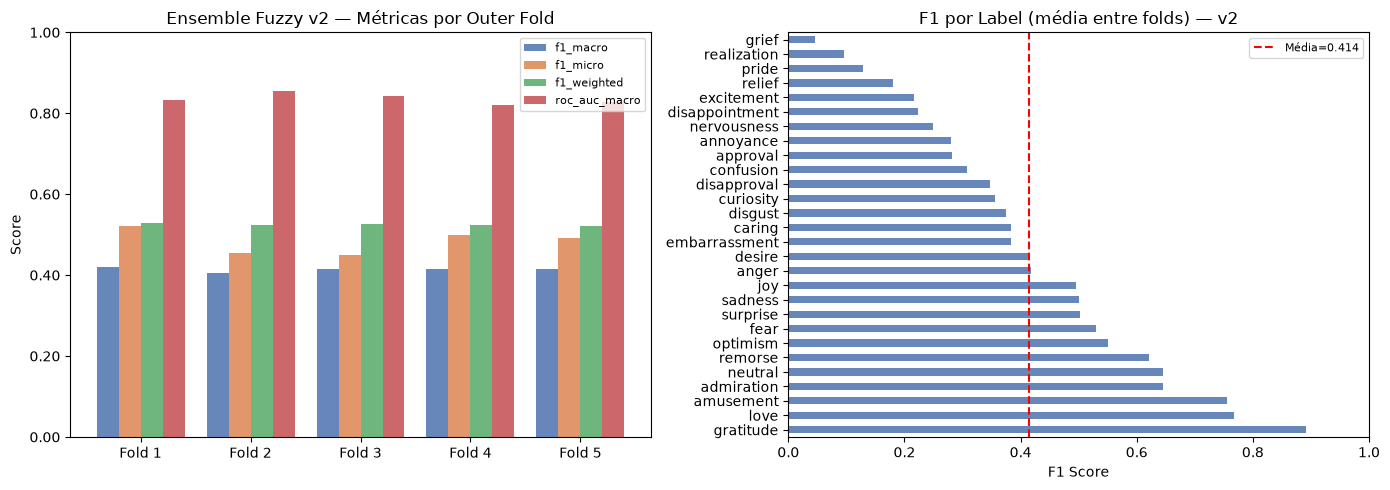

Figura salva em ..\data\out\ensemble_fuzzy_2\ensemble_fuzzy2_metrics.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metric_plot = ["f1_macro", "f1_micro", "f1_weighted", "roc_auc_macro"]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

ax = axes[0]
x = np.arange(len(df_results)); width = 0.20
for i, (met, col) in enumerate(zip(metric_plot, colors)):
    ax.bar(x + i * width, df_results[met], width, label=met, color=col, alpha=0.85)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f"Fold {k}" for k in df_results.index])
ax.set_ylim(0, 1)
ax.set_title("Ensemble Fuzzy v2 — Métricas por Outer Fold")
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.set_ylabel("Score")

ax2 = axes[1]
f1_per_label_mean.plot.barh(ax=ax2, color="#4C72B0", alpha=0.85)
ax2.set_title("F1 por Label (média entre folds) — v2")
ax2.set_xlabel("F1 Score"); ax2.set_xlim(0, 1)
ax2.axvline(f1_per_label_mean.mean(), color="red", linestyle="--",
            label=f"Média={f1_per_label_mean.mean():.3f}")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / "ensemble_fuzzy2_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura salva em {OUT_DIR / 'ensemble_fuzzy2_metrics.png'}")


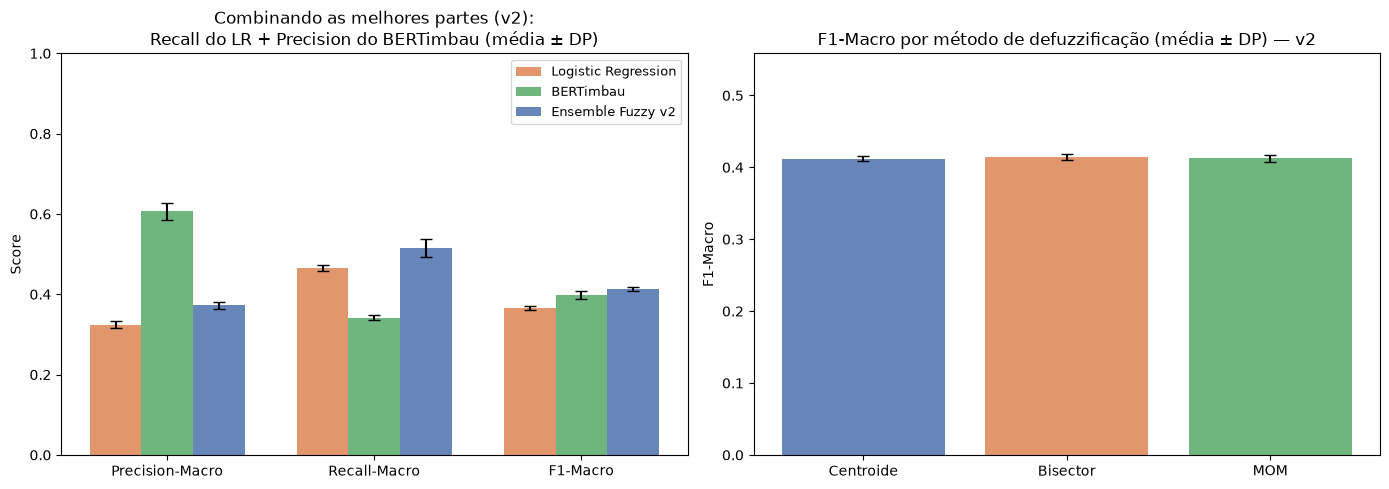

Figura salva em ..\data\out\ensemble_fuzzy_2\ensemble_fuzzy2_comparacao.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models = ["Logistic Regression", "BERTimbau", "Ensemble Fuzzy v2"]
dfs    = [df_lr, df_bert, df_fz]
mcolors = ["#DD8452", "#55A868", "#4C72B0"]

ax = axes[0]
mets = ["precision_macro", "recall_macro", "f1_macro"]
met_labels = ["Precision-Macro", "Recall-Macro", "F1-Macro"]
x = np.arange(len(mets)); width = 0.25
for i, (name, d, c) in enumerate(zip(models, dfs, mcolors)):
    means = [d[m].mean() for m in mets]; stds = [d[m].std() for m in mets]
    ax.bar(x + i * width, means, width, yerr=stds, capsize=4, label=name, color=c, alpha=0.85)
ax.set_xticks(x + width); ax.set_xticklabels(met_labels); ax.set_ylim(0, 1)
ax.set_title("Combinando as melhores partes (v2):\nRecall do LR + Precision do BERTimbau (média ± DP)")
ax.legend(fontsize=9); ax.set_ylabel("Score")

ax3 = axes[1]
defz_means = {m: np.mean([x["f1_macro"] for x in method_fold_metrics[m]]) for m in DEFUZZ_METHODS}
defz_stds  = {m: np.std([x["f1_macro"] for x in method_fold_metrics[m]], ddof=1) for m in DEFUZZ_METHODS}
names = {"centroid": "Centroide", "bisector": "Bisector", "mom": "MOM"}
ax3.bar([names[m] for m in DEFUZZ_METHODS],
        [defz_means[m] for m in DEFUZZ_METHODS],
        yerr=[defz_stds[m] for m in DEFUZZ_METHODS],
        capsize=4, color=["#4C72B0", "#DD8452", "#55A868"], alpha=0.85)
ax3.set_title("F1-Macro por método de defuzzificação (média ± DP) — v2")
ax3.set_ylabel("F1-Macro"); ax3.set_ylim(0, max(defz_means.values()) * 1.35)

plt.tight_layout()
plt.savefig(OUT_DIR / "ensemble_fuzzy2_comparacao.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura salva em {OUT_DIR / 'ensemble_fuzzy2_comparacao.png'}")


## 10. Interpretabilidade — Pertinência Emocional

Igual à v1: MFs geradas automaticamente (agora com partição fina para `p_lr`/`p_bert`),
base de regras Wang–Mendel, distribuição dos graus por classe e explicação de um texto.

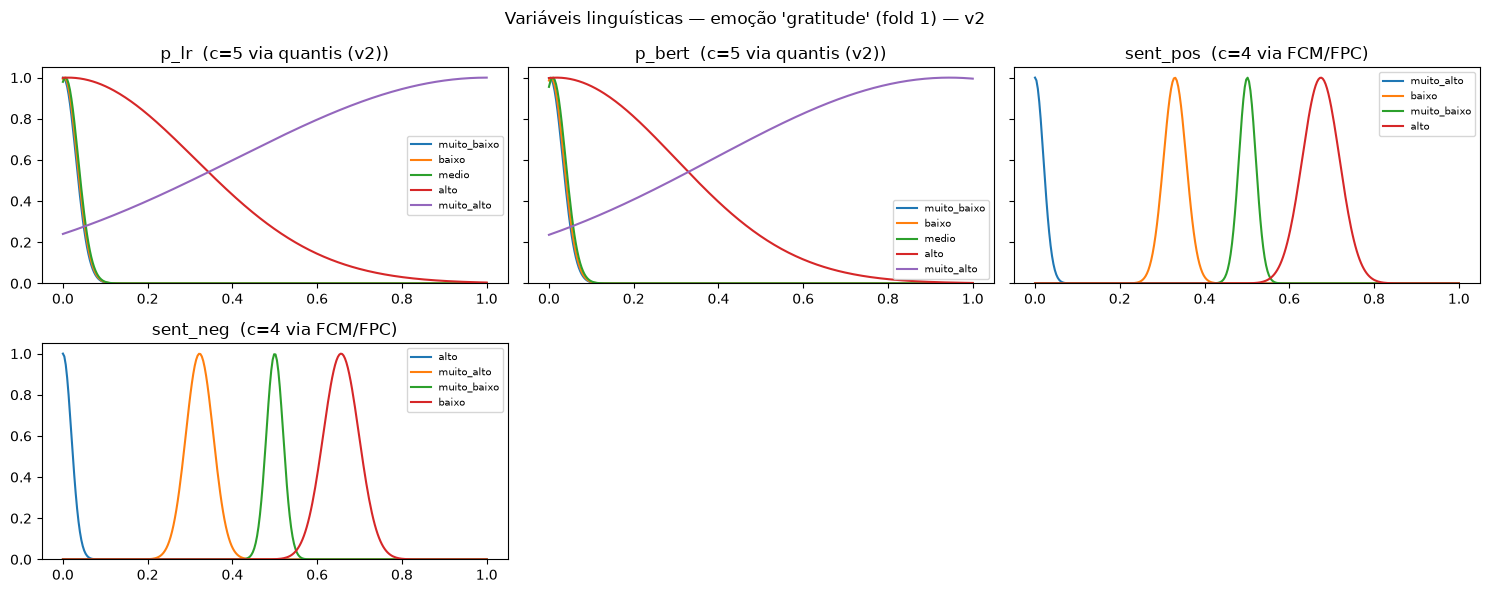

Base de regras da emoção 'gratitude' (fold 1): 80 regras (Wang–Mendel). Top 12 por suporte:

  SE p_lr é ALTO E p_bert é ALTO E sent_pos é MUITO_ALTO E sent_neg é ALTO ENTÃO pertinência(gratitude) é BAIXA  [conf=0.96, suporte=6161.4]
  SE p_lr é MUITO_ALTO E p_bert é MUITO_ALTO E sent_pos é MUITO_BAIXO E sent_neg é ALTO ENTÃO pertinência(gratitude) é ALTA  [conf=0.99, suporte=4879.2]
  SE p_lr é ALTO E p_bert é BAIXO E sent_pos é MUITO_ALTO E sent_neg é ALTO ENTÃO pertinência(gratitude) é BAIXA  [conf=0.99, suporte=3912.6]
  SE p_lr é ALTO E p_bert é ALTO E sent_pos é MUITO_BAIXO E sent_neg é ALTO ENTÃO pertinência(gratitude) é BAIXA  [conf=0.90, suporte=3387.7]
  SE p_lr é ALTO E p_bert é MUITO_BAIXO E sent_pos é MUITO_ALTO E sent_neg é ALTO ENTÃO pertinência(gratitude) é BAIXA  [conf=1.00, suporte=2458.1]
  SE p_lr é BAIXO E p_bert é ALTO E sent_pos é MUITO_ALTO E sent_neg é ALTO ENTÃO pertinência(gratitude) é BAIXA  [conf=0.99, suporte=2342.9]
  SE p_lr é BAIXO E p_bert é BAIXO E se

In [16]:
EMO_DEMO  = "gratitude"
FOLD_DEMO = 1
sys_demo = fuzzy_systems[FOLD_DEMO][EMO_DEMO]

n_v = len(sys_demo["fvars"])
ncols = min(3, n_v); nrows = int(np.ceil(n_v / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows), sharey=True)
axes = np.atleast_1d(axes).ravel()
xx = np.linspace(0, 1, 300)
for ax, fv in zip(axes, sys_demo["fvars"]):
    M = fv.memberships(xx)
    for t in range(fv.n_terms):
        ax.plot(xx, M[:, t], label=fv.terms[t])
    kind = "quantis (v2)" if fv.name in PROB_VARS else "FCM/FPC"
    ax.set_title(f"{fv.name}  (c={fv.n_terms} via {kind})")
    ax.set_ylim(0, 1.05); ax.legend(fontsize=7)
for ax in axes[n_v:]:
    ax.axis("off")
fig.suptitle(f"Variáveis linguísticas — emoção '{EMO_DEMO}' (fold {FOLD_DEMO}) — v2")
plt.tight_layout()
plt.savefig(OUT_DIR / f"mfs_{EMO_DEMO}_fold{FOLD_DEMO}_v2.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Base de regras da emoção '{EMO_DEMO}' (fold {FOLD_DEMO}): "
      f"{len(sys_demo['rules'])} regras (Wang–Mendel). Top 12 por suporte:\n")
for r in sys_demo["rules"][:12]:
    print(" ", rule_to_text(r, sys_demo["fvars"], EMO_DEMO))
print(f"\nLimiar por defuzz (calibração): "
      f"{ {m: round(t,2) for m,t in sys_demo['thresholds'].items()} } | "
      f"peso de classe positiva: {sys_demo['pos_weight']:.2f}")


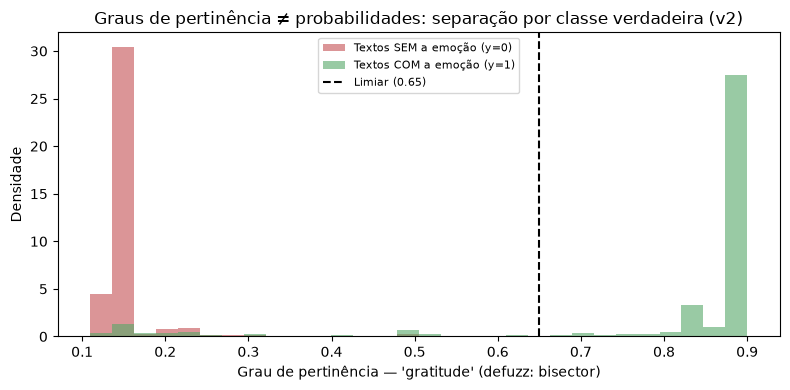

TEXTO (fold 1, idx 11): "obrigada realmente aprecio sua resposta"
Emoção analisada: gratitude | rótulo verdadeiro: 1

Entradas crisp: p_lr=1.000 | p_bert=0.949 | sent_pos=0.500 | sent_neg=0.000

Fuzzificação (grau em cada termo linguístico):
  p_lr     : muito_baixo=0.00, baixo=0.00, medio=0.00, alto=0.00, muito_alto=1.00
  p_bert   : muito_baixo=0.00, baixo=0.00, medio=0.00, alto=0.00, muito_alto=1.00
  sent_pos : muito_alto=0.00, baixo=0.00, muito_baixo=1.00, alto=0.00
  sent_neg : alto=1.00, muito_alto=0.00, muito_baixo=0.00, baixo=0.00

Top 5 regras disparadas:
  [0.987] SE p_lr é MUITO_ALTO E p_bert é MUITO_ALTO E sent_pos é MUITO_BAIXO E sent_neg é ALTO ENTÃO pertinência(gratitude) é ALTA  [conf=0.99, suporte=4879.2]
  [0.003] SE p_lr é ALTO E p_bert é MUITO_ALTO E sent_pos é MUITO_BAIXO E sent_neg é ALTO ENTÃO pertinência(gratitude) é ALTA  [conf=0.78, suporte=62.8]
  [0.002] SE p_lr é MUITO_ALTO E p_bert é ALTO E sent_pos é MUITO_BAIXO E sent_neg é ALTO ENTÃO pertinência(gratit

In [17]:
sel = selected_methods[FOLD_DEMO]
j_demo = EMOTION_COLS.index(EMO_DEMO)
pert = pertinence_test[FOLD_DEMO][sel][:, j_demo]
y_true_demo = Y_folds[FOLD_DEMO][:, j_demo]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pert[y_true_demo == 0], bins=30, alpha=0.6, density=True,
        label="Textos SEM a emoção (y=0)", color="#C44E52")
ax.hist(pert[y_true_demo == 1], bins=30, alpha=0.6, density=True,
        label="Textos COM a emoção (y=1)", color="#55A868")
ax.axvline(sys_demo["thresholds"][sel], color="k", linestyle="--",
           label=f"Limiar ({sys_demo['thresholds'][sel]:.2f})")
ax.set_xlabel(f"Grau de pertinência — '{EMO_DEMO}' (defuzz: {sel})")
ax.set_ylabel("Densidade")
ax.set_title("Graus de pertinência ≠ probabilidades: separação por classe verdadeira (v2)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / f"pertinencia_{EMO_DEMO}_fold{FOLD_DEMO}_v2.png", dpi=150, bbox_inches="tight")
plt.show()

def explicar_texto(fold, i, emotion, top_rules=5):
    j = EMOTION_COLS.index(emotion)
    system = fuzzy_systems[fold][emotion]
    outras_cal, outras_te = aggregate_outras(
        np.vstack([LEX_folds[k] for k in folds_data if k != fold]), LEX_folds[fold])
    inp = build_emotion_inputs(j, P_LR_folds[fold], P_BERT_folds[fold], SENT_folds[fold], outras_te)
    x = {v: inp[v][i] for v in INPUT_VARS}

    print(f"TEXTO (fold {fold}, idx {i}): \"{TEXT_folds[fold][i][:200]}\"")
    print(f"Emoção analisada: {emotion} | rótulo verdadeiro: {Y_folds[fold][i, j]}")
    print(f"\nEntradas crisp: " + " | ".join(f"{v}={x[v]:.3f}" for v in INPUT_VARS))

    print("\nFuzzificação (grau em cada termo linguístico):")
    M_i = []
    for fv in system["fvars"]:
        mu = fv.memberships(np.array([x[fv.name]]))[0]
        M_i.append(mu)
        print(f"  {fv.name:9s}: " + ", ".join(f"{t}={m:.2f}" for t, m in zip(fv.terms, mu)))

    fires = []
    for r in system["rules"]:
        f = np.prod([M_i[q][a] for q, a in enumerate(r["antecedent"])]) * r["conf"]
        fires.append((f, r))
    fires.sort(key=lambda z: z[0], reverse=True)
    print(f"\nTop {top_rules} regras disparadas:")
    for f, r in fires[:top_rules]:
        print(f"  [{f:.3f}] {rule_to_text(r, system['fvars'], emotion)}")

    M_list = [fv.memberships(np.array([x[fv.name]])) for fv in system["fvars"]]
    W = fuzzy_inference(M_list, system["rules"]); pj = defuzzify(W)
    print("\nGraus de pertinência (defuzzificação):")
    for m, p in pj.items():
        thr = system["thresholds"][m]
        dec = "PRESENTE" if p[0] >= thr else "ausente"
        print(f"  {m:9s}: pertinência = {p[0]:.3f}  (limiar {thr:.2f} → {dec})")

def pertinencias_do_texto(fold, i):
    sel = selected_methods[fold]
    s = pd.Series(pertinence_test[fold][sel][i], index=EMOTION_COLS)
    return s.sort_values(ascending=False)

cand = np.where(y_true_demo == 1)[0]
i_demo = int(cand[0]) if len(cand) else 0
explicar_texto(FOLD_DEMO, i_demo, EMO_DEMO)
print("\nGraus de pertinência de TODAS as emoções para esse texto (top 8):")
print(pertinencias_do_texto(FOLD_DEMO, i_demo).head(8).round(3))


## 11. Análise de erros

Quantos falsos negativos do BERTimbau o Fuzzy recupera e quantos falsos positivos do LR ele
corrige — o coração da tese do ensemble. Na v2, espera-se **mais correção de FP do LR** graças
ao *lift* de pureza no consequente ALTA.

In [18]:
tot = dict(fn_bert=0, fn_bert_recuperados=0, fp_lr=0, fp_lr_corrigidos=0,
           novos_fp=0, novos_fn=0)

for k in folds_data:
    Yt = Y_folds[k]
    pf, pl, pb = pred_store[k]["fuzzy"], pred_store[k]["lr"], pred_store[k]["bert"]

    fn_bert = (Yt == 1) & (pb == 0)
    tot["fn_bert"] += int(fn_bert.sum())
    tot["fn_bert_recuperados"] += int((fn_bert & (pf == 1)).sum())

    fp_lr = (Yt == 0) & (pl == 1)
    tot["fp_lr"] += int(fp_lr.sum())
    tot["fp_lr_corrigidos"] += int((fp_lr & (pf == 0)).sum())

    tot["novos_fp"] += int(((Yt == 0) & (pf == 1) & (pl == 0) & (pb == 0)).sum())
    tot["novos_fn"] += int(((Yt == 1) & (pf == 0) & ((pl == 1) | (pb == 1))).sum())

print("===== ANÁLISE DE ERROS (agregado, 5 outer folds) — v2 =====")
print(f"Falsos negativos do BERTimbau ............: {tot['fn_bert']}")
print(f"  → recuperados pelo Fuzzy (ganho recall) : {tot['fn_bert_recuperados']} "
      f"({100*tot['fn_bert_recuperados']/max(tot['fn_bert'],1):.1f}%)")
print(f"Falsos positivos do LR ...................: {tot['fp_lr']}")
print(f"  → corrigidos pelo Fuzzy (ganho precision): {tot['fp_lr_corrigidos']} "
      f"({100*tot['fp_lr_corrigidos']/max(tot['fp_lr'],1):.1f}%)")
print(f"Novos FP introduzidos pelo Fuzzy .........: {tot['novos_fp']}")
print(f"Novos FN introduzidos pelo Fuzzy .........: {tot['novos_fn']}")

print("\nTop 5 emoções com MAIOR ganho de F1 (vs melhor baseline):")
display(df_label_comp.sort_values("Δ vs melhor baseline", ascending=False)
        .head(5)[["Fuzzy", "LR", "BERTimbau", "Δ vs melhor baseline"]].round(4))
print("Top 5 emoções com PIOR resultado (vs melhor baseline):")
display(df_label_comp.sort_values("Δ vs melhor baseline")
        .head(5)[["Fuzzy", "LR", "BERTimbau", "Δ vs melhor baseline"]].round(4))

def exemplos(cond_fn, titulo, n_show=3):
    print(f"\n───── {titulo} ─────")
    shown = 0
    for k in folds_data:
        Yt = Y_folds[k]
        pf, pl, pb = pred_store[k]["fuzzy"], pred_store[k]["lr"], pred_store[k]["bert"]
        mask = cond_fn(Yt, pf, pl, pb)
        idxs = np.argwhere(mask)
        for i, j in idxs[: max(0, n_show - shown)]:
            sel_k = selected_methods[k]
            print(f"  [fold {k} | {EMOTION_COLS[j]}] "
                  f"P_LR={P_LR_folds[k][i, j]:.2f} P_BERT={P_BERT_folds[k][i, j]:.2f} "
                  f"pertinência={pertinence_test[k][sel_k][i, j]:.2f}")
            print(f"    \"{TEXT_folds[k][i][:140]}\"")
            shown += 1
        if shown >= n_show:
            break

exemplos(lambda Y, f, l, b: (Y == 1) & (b == 0) & (f == 1),
         "FN do BERTimbau recuperados pelo Fuzzy (recall herdado do LR)")
exemplos(lambda Y, f, l, b: (Y == 0) & (l == 1) & (f == 0),
         "FP do LR corrigidos pelo Fuzzy (precision herdada do BERTimbau)")
exemplos(lambda Y, f, l, b: (Y == 1) & (f == 0) & ((l == 1) | (b == 1)),
         "Casos em que o Fuzzy perdeu um acerto de algum baseline (custo do compromisso)")


===== ANÁLISE DE ERROS (agregado, 5 outer folds) — v2 =====
Falsos negativos do BERTimbau ............: 38115
  → recuperados pelo Fuzzy (ganho recall) : 13071 (34.3%)
Falsos positivos do LR ...................: 67533
  → corrigidos pelo Fuzzy (ganho precision): 43317 (64.1%)
Novos FP introduzidos pelo Fuzzy .........: 29530
Novos FN introduzidos pelo Fuzzy .........: 4955

Top 5 emoções com MAIOR ganho de F1 (vs melhor baseline):


,Fuzzy,LR,BERTimbau,Δ vs melhor baseline
curiosity,0.3553,0.2179,0.1828,0.1374
disapproval,0.3475,0.2326,0.1356,0.1150
caring,0.3832,0.2909,0.2958,0.0874
approval,0.2827,0.2080,0.0945,0.0747
annoyance,0.2797,0.2092,0.0045,0.0706


Top 5 emoções com PIOR resultado (vs melhor baseline):


,Fuzzy,LR,BERTimbau,Δ vs melhor baseline
pride,0.1282,0.3316,0.5000,-0.3719
grief,0.0452,0.1985,0.2588,-0.2136
nervousness,0.2484,0.2093,0.3583,-0.1098
relief,0.1799,0.1289,0.2753,-0.0954
embarrassment,0.3843,0.1611,0.4643,-0.0800



───── FN do BERTimbau recuperados pelo Fuzzy (recall herdado do LR) ─────
  [fold 1 | annoyance] P_LR=0.13 P_BERT=0.28 pertinência=0.51
    "isso cheira positivamente lar abusivo"
  [fold 1 | excitement] P_LR=0.95 P_BERT=0.40 pertinência=0.50
    "vamos colocar coisas volta nos trilhos feliz ano novo"
  [fold 1 | admiration] P_LR=0.74 P_BERT=0.30 pertinência=0.84
    "obrigada realmente aprecio sua resposta"

───── FP do LR corrigidos pelo Fuzzy (precision herdada do BERTimbau) ─────
  [fold 1 | annoyance] P_LR=0.52 P_BERT=0.08 pertinência=0.27
    "tanto tempo economizado nao"
  [fold 1 | approval] P_LR=0.50 P_BERT=0.03 pertinência=0.16
    "tanto tempo economizado nao"
  [fold 1 | realization] P_LR=0.52 P_BERT=0.01 pertinência=0.17
    "fico feliz ouvi-lo voce merece sua melhor vida sem esse abuso negatividade"

───── Casos em que o Fuzzy perdeu um acerto de algum baseline (custo do compromisso) ─────
  [fold 1 | caring] P_LR=0.92 P_BERT=0.08 pertinência=0.38
    "fico feliz ouvi-lo

## 12. Exportação dos resultados (diretório v2)

Todos os arquivos vão para `../data/out/ensemble_fuzzy_2` com sufixo `_v2`/`2`, **sem tocar**
nas saídas do ensemble original. Inclui um CSV de comparação direta v1×v2 quando a v1 existe.

In [19]:
df_results.to_csv(OUT_DIR / "ensemble_fuzzy2_global_metrics.csv")
f1_per_label_folds.to_csv(OUT_DIR / "ensemble_fuzzy2_f1_per_label.csv")
df_comparison.to_csv(OUT_DIR / "comparacao_LR_BERT_Fuzzy_v2.csv")
df_label_comp.to_csv(OUT_DIR / "f1_por_label_comparacao_v2.csv")
df_defuzz.to_csv(OUT_DIR / "comparacao_defuzzificacao_v2.csv")
if df_v1v2 is not None:
    df_v1v2.to_csv(OUT_DIR / "comparacao_v1_v2.csv")

# ── Graus de pertinência (bloco 9) — dataset completo, out-of-fold ─
pert_frames = []
for k in folds_data:
    sel_k = selected_methods[k]
    dfp = pd.DataFrame(pertinence_test[k][sel_k],
                       columns=[f"pert_{e}" for e in EMOTION_COLS])
    dfp.insert(0, "fold", k); dfp.insert(1, "defuzz", sel_k)
    dfp.insert(2, TEXT_COL, TEXT_folds[k])
    for j, e in enumerate(EMOTION_COLS):
        dfp[f"pred_{e}"] = pred_store[k]["fuzzy"][:, j]
        dfp[f"true_{e}"] = Y_folds[k][:, j]
    pert_frames.append(dfp)
df_pertinencias = pd.concat(pert_frames, ignore_index=True)
df_pertinencias.to_parquet(OUT_DIR / "graus_pertinencia_oof_v2.parquet", index=False)

# ── Base de regras exportada (interpretabilidade/auditoria) ──────
rules_records = []
for k, systems in fuzzy_systems.items():
    for emo, s in systems.items():
        for r in s["rules"]:
            rules_records.append({
                "fold": k, "emocao": emo,
                "regra": rule_to_text(r, s["fvars"], emo),
                "consequente": OUT_TERMS[r["consequent"]],
                "confianca": round(r["conf"], 4),
                "suporte": round(r["support"], 2),
            })
pd.DataFrame(rules_records).to_csv(OUT_DIR / "base_de_regras_v2.csv", index=False)

# ── Resumo final JSON ────────────────────────────────────────────
summary_dict = {
    "model": "Ensemble Fuzzy Mamdani v2 (LR + BERTimbau + sentimento)",
    "versao": "v2",
    "mudancas_v2": CHANGES_V2,
    "base_teorica": "Anwar et al. (2024), PLoS ONE 19(5):e0300279 — fuzzy ensemble de modelos",
    "geracao_mfs": (f"p_lr/p_bert: {PROB_N_TERMS} termos por quantis (v2); "
                    f"demais: Fuzzy C-Means (c por FPC em {list(FCM_C_CANDIDATES)})"),
    "geracao_regras": (f"Wang–Mendel (máx. {MAX_RULES}/emoção; pos_weight={POS_WEIGHT_MODE}"
                       f"<={POS_WEIGHT_CAP}; lift ALTA={LIFT_ALTA})"),
    "defuzzificacao": {"metodos_avaliados": list(DEFUZZ_METHODS),
                       "selecionado_por_fold": {str(k): v for k, v in selected_methods.items()}},
    "sentiment_backend": SENTIMENT_BACKEND,
    "input_vars": INPUT_VARS,
    "strategy": f"Nested CV ({N_OUTER_FOLDS} outer folds; calibração fuzzy 100% no outer-train, OOF)",
    "n_labels": N_LABELS,
    "f1_macro_mean": round(float(df_results["f1_macro"].mean()), 4),
    "f1_macro_std" : round(float(df_results["f1_macro"].std()),  4),
    "f1_micro_mean": round(float(df_results["f1_micro"].mean()), 4),
    "f1_micro_std" : round(float(df_results["f1_micro"].std()),  4),
    "precision_macro_mean": round(float(df_results["precision_macro"].mean()), 4),
    "precision_macro_std" : round(float(df_results["precision_macro"].std()),  4),
    "recall_macro_mean": round(float(df_results["recall_macro"].mean()), 4),
    "recall_macro_std" : round(float(df_results["recall_macro"].std()),  4),
    "roc_auc_mean": round(float(df_results["roc_auc_macro"].mean()), 4),
    "roc_auc_std" : round(float(df_results["roc_auc_macro"].std()),  4),
    "wilcoxon": wilcoxon_results,
    "baselines_no_mesmo_protocolo": {
        "LR":   {"f1_macro": f"{df_lr['f1_macro'].mean():.4f} ± {df_lr['f1_macro'].std():.4f}",
                 "precision_macro": f"{df_lr['precision_macro'].mean():.4f}",
                 "recall_macro": f"{df_lr['recall_macro'].mean():.4f}"},
        "BERT": {"f1_macro": f"{df_bert['f1_macro'].mean():.4f} ± {df_bert['f1_macro'].std():.4f}",
                 "precision_macro": f"{df_bert['precision_macro'].mean():.4f}",
                 "recall_macro": f"{df_bert['recall_macro'].mean():.4f}"},
    },
}
with open(OUT_DIR / "ensemble_fuzzy2_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary_dict, f, indent=2, ensure_ascii=False)

print("Arquivos exportados para", OUT_DIR.resolve())
print(json.dumps(summary_dict, indent=2, ensure_ascii=False))


Arquivos exportados para C:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\data\out\ensemble_fuzzy_2
{
  "model": "Ensemble Fuzzy Mamdani v2 (LR + BERTimbau + sentimento)",
  "versao": "v2",
  "mudancas_v2": {
    "prob_inputs_fine_partition": {
      "vars": [
        "p_lr",
        "p_bert"
      ],
      "n_terms": 5
    },
    "pos_weight": {
      "mode": "sqrt",
      "cap": 4.0
    },
    "consequente_alta_lift": 1.0,
    "input_vars": [
      "p_lr",
      "p_bert",
      "sent_pos",
      "sent_neg"
    ],
    "max_rules": 80
  },
  "base_teorica": "Anwar et al. (2024), PLoS ONE 19(5):e0300279 — fuzzy ensemble de modelos",
  "geracao_mfs": "p_lr/p_bert: 5 termos por quantis (v2); demais: Fuzzy C-Means (c por FPC em [2, 3, 4])",
  "geracao_regras": "Wang–Mendel (máx. 80/emoção; pos_weight=sqrt<=4.0; lift ALTA=1.0)",
  "defuzzificacao": {
    "metodos_avaliados": [
      "centroid",
      "bisector",
      "mom"
    ],
    "selecionado_por_fold": 